# GSE281807 — GeoMx DSP Analysis

**Dataset:** Broad rim lesions in Multiple Sclerosis  
**Platform:** NanoString GeoMx Digital Spatial Profiler (Whole Transcriptome Atlas)  
**Samples:** 296 ROIs from 34 patients (31 MS + 3 controls)  
**Lesion types:** NAWM, RIM, BRL, active, mixed  
**Cell segmentation:** CD68+ (macrophages/microglia)

In [1]:
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(6, 4))

/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## 1. Load data

In [2]:
adata = ad.read_h5ad("../data/GSE281807/processed/GSE281807_geomx.h5ad")
print(adata)
adata.obs.head()

AnnData object with n_obs × n_vars = 296 × 18677
    obs: 'gsm_id', 'scan_id', 'plate_id', 'well', 'raw_reads', 'trimmed_reads', 'aligned_reads', 'umi_q30', 'rts_q30', 'title', 'patient', 'lesion_type', 'replicate', 'condition', 'tissue', 'cell_type', 'location'
    var: 'code_class'
    uns: 'dataset', 'organism', 'platform', 'title'


,gsm_id,scan_id,plate_id,well,raw_reads,trimmed_reads,aligned_reads,umi_q30,rts_q30,title,patient,lesion_type,replicate,condition,tissue,cell_type,location
gsm_id,,,,,,,,,,,,,,,,,
GSM8210328,GSM8210328,DSP-1001660021304-C-A02,1001660021304,A02,4883768,4869121,4699939,0.9907,0.9906,MS3a_NAWM_rep1,MS3a,NAWM,1,MS,"Brain, MS Autopsie",CD68 positive,NAWM/PPWM
GSM8210329,GSM8210329,DSP-1001660021304-C-C12,1001660021304,C12,2165275,2105878,2030346,0.9913,0.9907,MS9_RIM_rep1,MS9,RIM,1,MS,"Brain, MS Autopsie",CD68 positive,lesion rim
GSM8210330,GSM8210330,DSP-1001660021304-C-D02,1001660021304,D02,3568815,3558111,3434453,0.9907,0.9909,MS9_RIM_rep2,MS9,RIM,2,MS,"Brain, MS Autopsie",CD68 positive,lesion rim
GSM8210331,GSM8210331,DSP-1001660021304-C-D04,1001660021304,D04,2928942,2893839,2789640,0.9912,0.9907,MS9_RIM_rep3,MS9,RIM,3,MS,"Brain, MS Autopsie",CD68 positive,lesion rim
GSM8210332,GSM8210332,DSP-1001660021304-C-D06,1001660021304,D06,2979076,2969273,2863675,0.9905,0.9906,MS9_RIM_rep4,MS9,RIM,4,MS,"Brain, MS Autopsie",CD68 positive,lesion rim


In [3]:
# Overview of sample composition
print("Lesion types:")
print(adata.obs['lesion_type'].value_counts())
print(f"\nPatients: {adata.obs['patient'].nunique()}")
print(f"Conditions: {adata.obs['condition'].value_counts().to_dict()}")

Lesion types:
lesion_type
NAWM      146
mixed      48
active     46
RIM        32
BRL        24
Name: count, dtype: int64

Patients: 34
Conditions: {'MS': 275, 'control': 21}


## 2. QC

In [4]:
# Store raw counts
adata.raw = adata.copy()

# Separate negative probes for QC
neg_mask = adata.var['code_class'] == 'Negative'
neg_probe_counts = np.array(adata[:, neg_mask].X.todense()).flatten()
print(f"Negative probe (NegProbe-WTX) — median: {np.median(neg_probe_counts):.0f}, mean: {np.mean(neg_probe_counts):.0f}")

# Filter to endogenous genes only
adata = adata[:, adata.var['code_class'] == 'Endogenous'].copy()
print(f"\nAfter filtering: {adata.shape}")

Negative probe (NegProbe-WTX) — median: 1360, mean: 1724

After filtering: (296, 18676)


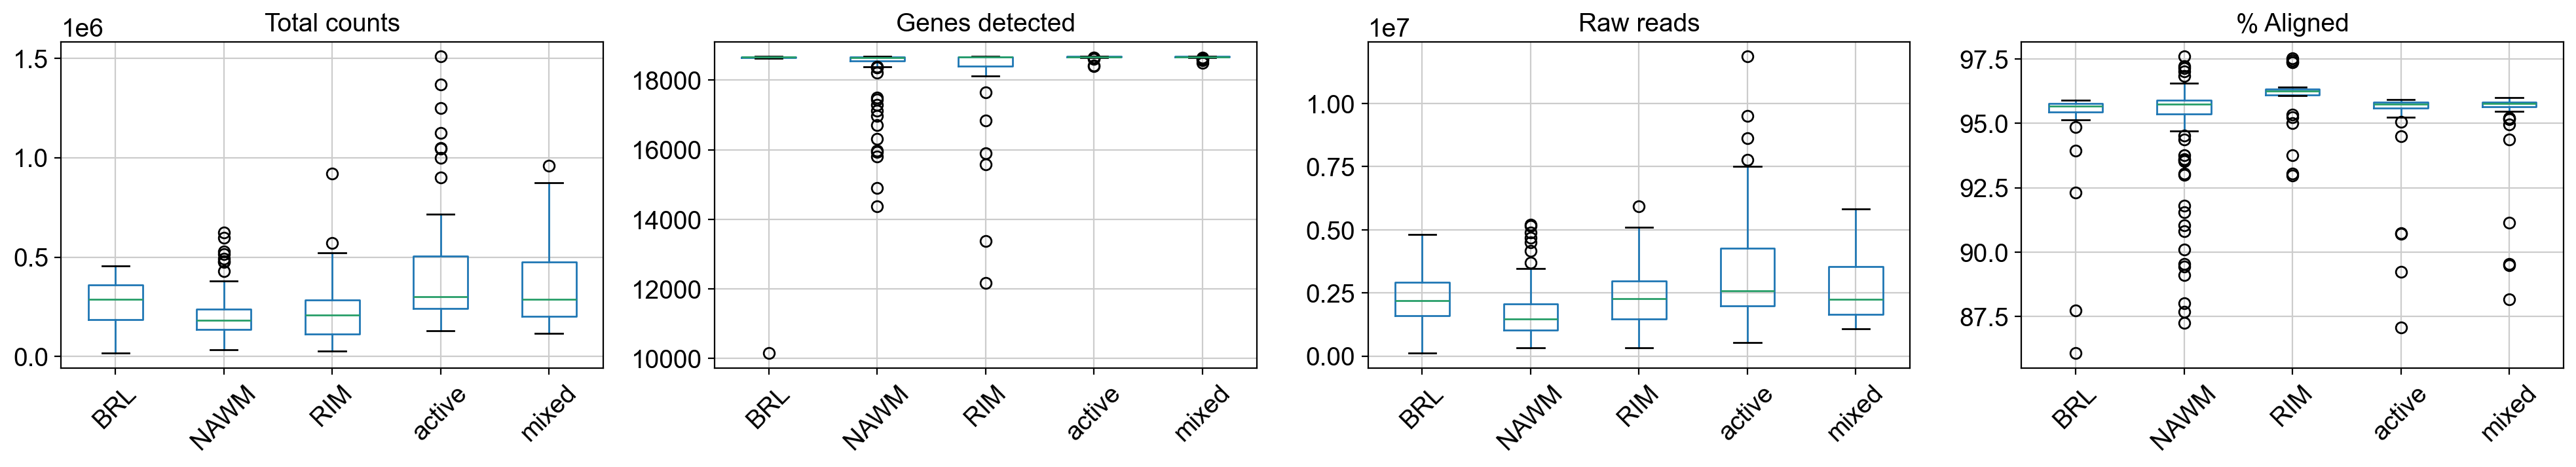

In [5]:
# Basic QC metrics
adata.obs['total_counts'] = np.array(adata.X.sum(axis=1)).flatten()
adata.obs['n_genes_detected'] = np.array((adata.X > 0).sum(axis=1)).flatten()
adata.obs['log_total_counts'] = np.log1p(adata.obs['total_counts'])
adata.obs['pct_aligned'] = adata.obs['aligned_reads'] / adata.obs['raw_reads'] * 100

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col, title in zip(axes, 
    ['total_counts', 'n_genes_detected', 'raw_reads', 'pct_aligned'],
    ['Total counts', 'Genes detected', 'Raw reads', '% Aligned']):
    adata.obs.boxplot(column=col, by='lesion_type', ax=ax, rot=45)
    ax.set_title(title)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

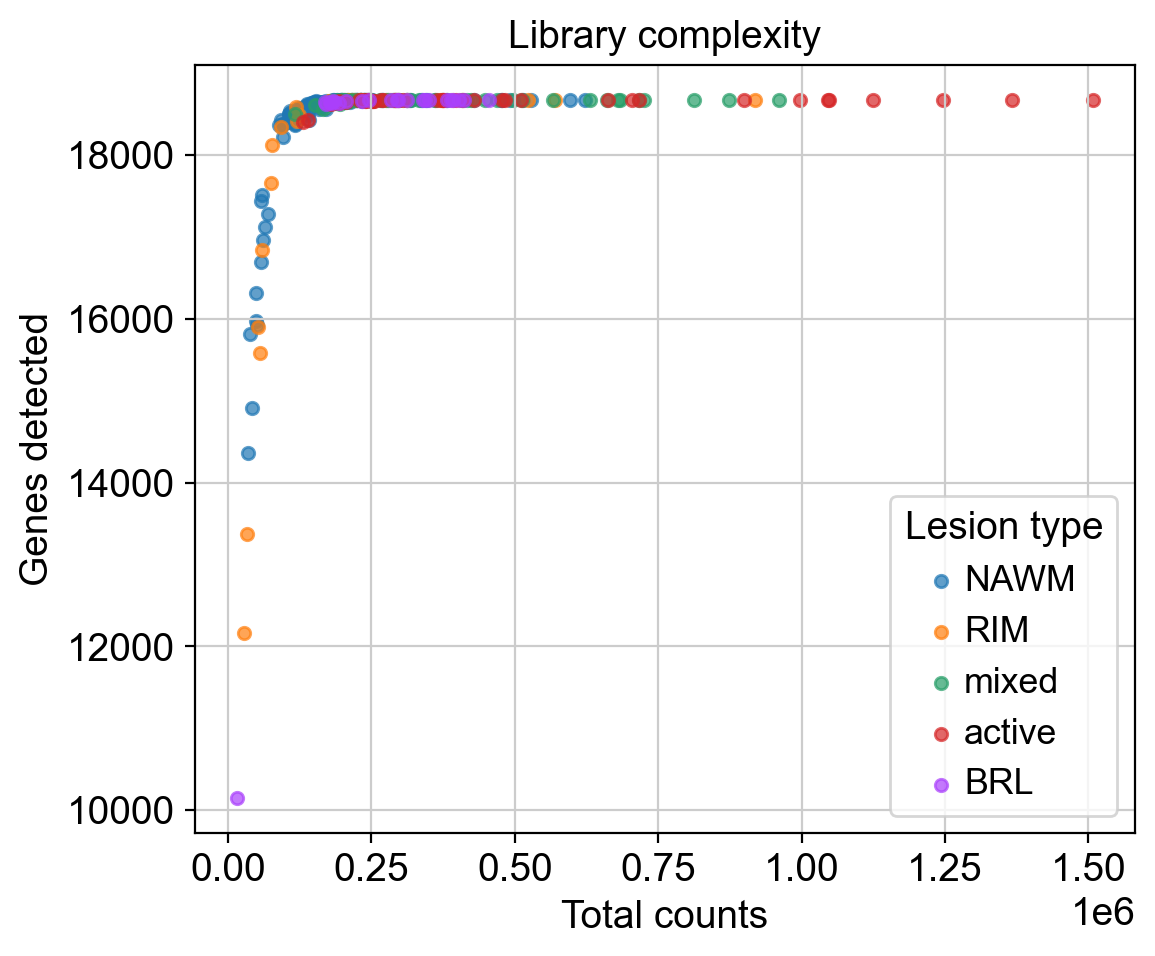

In [6]:
# QC scatter
fig, ax = plt.subplots(figsize=(6, 5))
for lt in adata.obs['lesion_type'].unique():
    mask = adata.obs['lesion_type'] == lt
    ax.scatter(
        adata.obs.loc[mask, 'total_counts'],
        adata.obs.loc[mask, 'n_genes_detected'],
        label=lt, alpha=0.7, s=20
    )
ax.set_xlabel('Total counts')
ax.set_ylabel('Genes detected')
ax.legend(title='Lesion type')
ax.set_title('Library complexity')
plt.tight_layout()
plt.show()

## 3. Normalization & dimensionality reduction

In [7]:
# Q3 normalization (standard for GeoMx)
# Each sample normalized to its 75th percentile of endogenous counts
X_dense = np.array(adata.X.todense(), dtype=np.float64)
q3 = np.percentile(X_dense, 75, axis=1, keepdims=True)
q3[q3 == 0] = 1  # avoid division by zero
geomean_q3 = np.exp(np.mean(np.log(q3[q3 > 0])))
X_norm = X_dense / q3 * geomean_q3

adata.layers['q3_norm'] = X_norm
adata.X = np.log1p(X_norm)
print(f"Q3 normalized + log1p. Shape: {adata.shape}")

Q3 normalized + log1p. Shape: (296, 18676)


In [8]:
# HVG selection, PCA, neighbors, UMAP
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
print(f"HVGs: {adata.var['highly_variable'].sum()}")

sc.tl.pca(adata, n_comps=30, use_highly_variable=True)
sc.pp.neighbors(adata, n_pcs=20)
sc.tl.umap(adata)

extracting highly variable genes
    finished (0:00:00)
HVGs: 3000
computing PCA
    with n_comps=30


/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 20


/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:03)
computing UMAP
    finished (0:00:01)


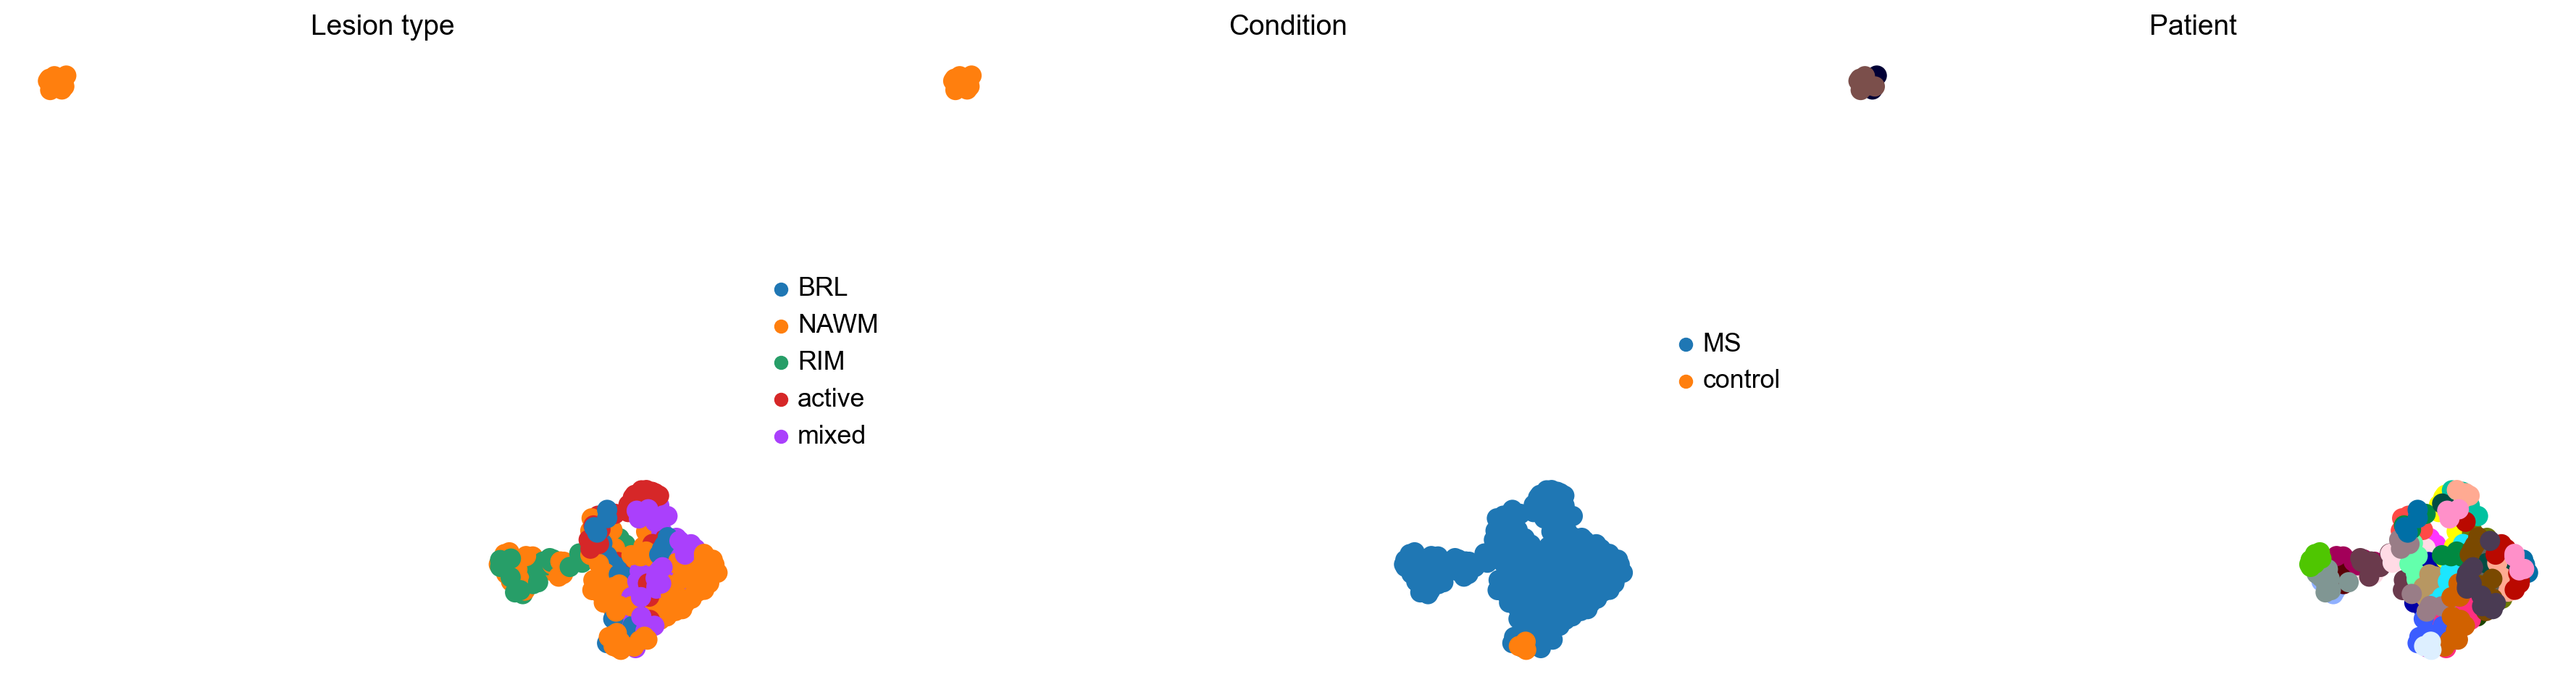

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(adata, color='lesion_type', ax=axes[0], show=False, title='Lesion type')
sc.pl.umap(adata, color='condition', ax=axes[1], show=False, title='Condition')
sc.pl.umap(adata, color='patient', ax=axes[2], show=False, title='Patient', legend_loc='none')
plt.tight_layout()
plt.show()

## 4. Differential expression — lesion types

ranking genes
    finished (0:00:03)


/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarnin

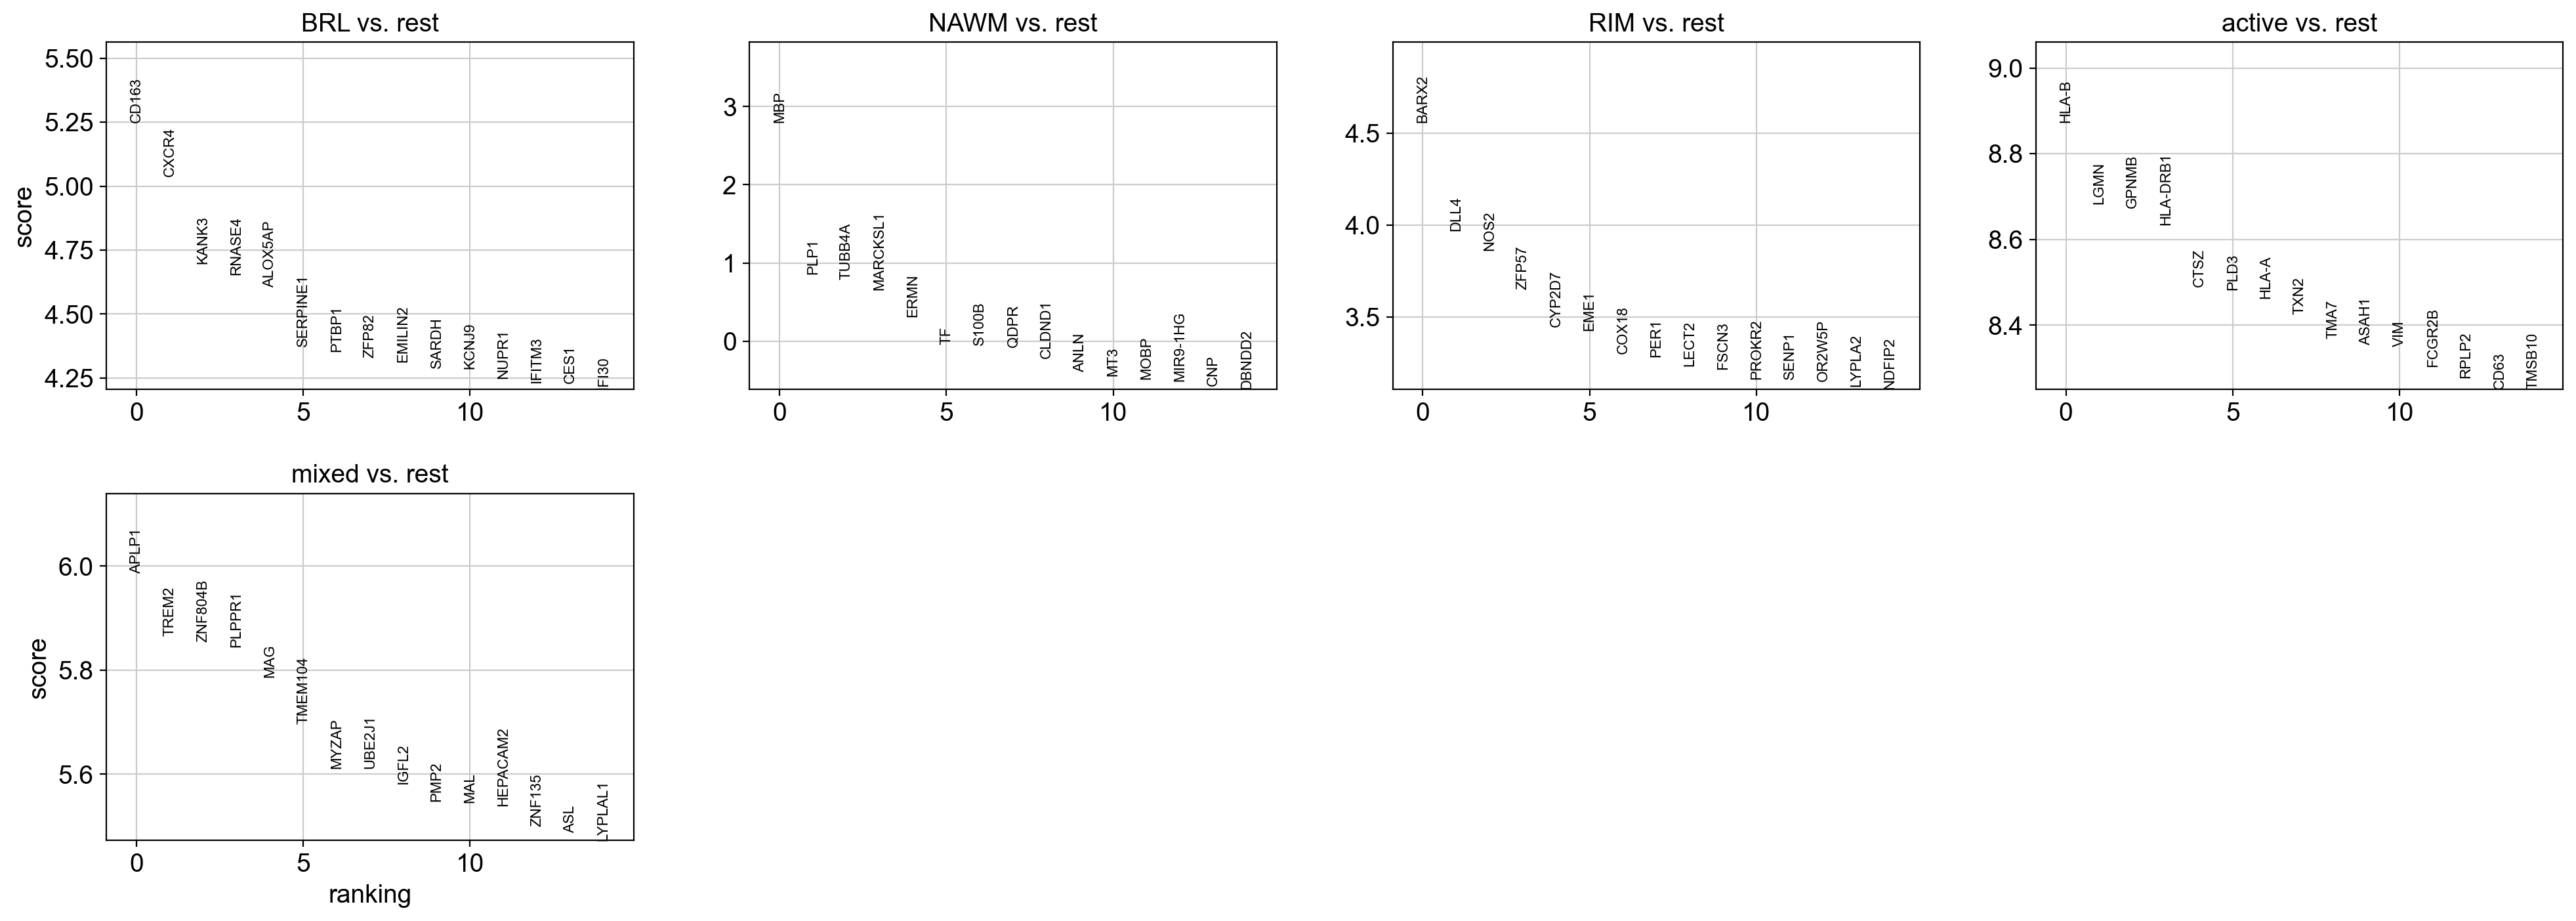

In [10]:
# Compare lesion types (MS samples only)
adata_ms = adata[adata.obs['condition'] == 'MS'].copy()

sc.tl.rank_genes_groups(adata_ms, groupby='lesion_type', method='wilcoxon')
sc.pl.rank_genes_groups(adata_ms, n_genes=15, sharey=False)

ranking genes
    finished (0:00:00)


/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


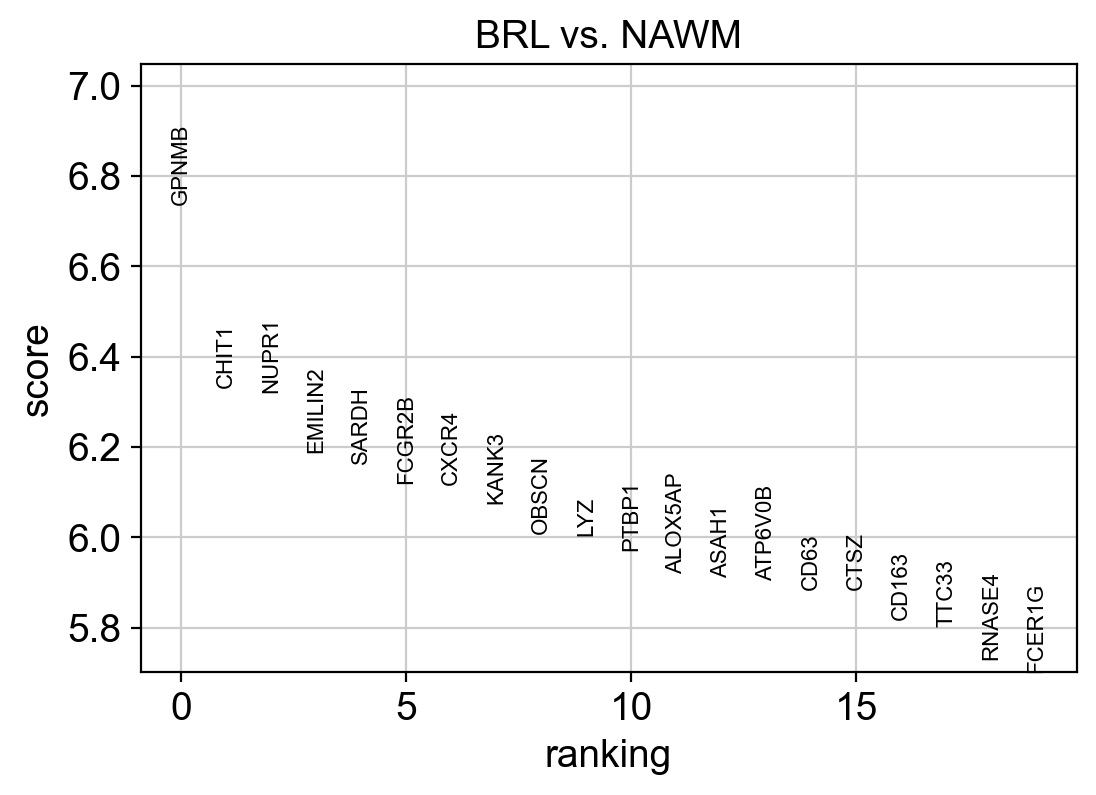

In [11]:
# BRL vs NAWM specifically
adata_brl_nawm = adata_ms[adata_ms.obs['lesion_type'].isin(['BRL', 'NAWM'])].copy()
sc.tl.rank_genes_groups(adata_brl_nawm, groupby='lesion_type', method='wilcoxon',
                        reference='NAWM')
sc.pl.rank_genes_groups(adata_brl_nawm, n_genes=20, sharey=False)

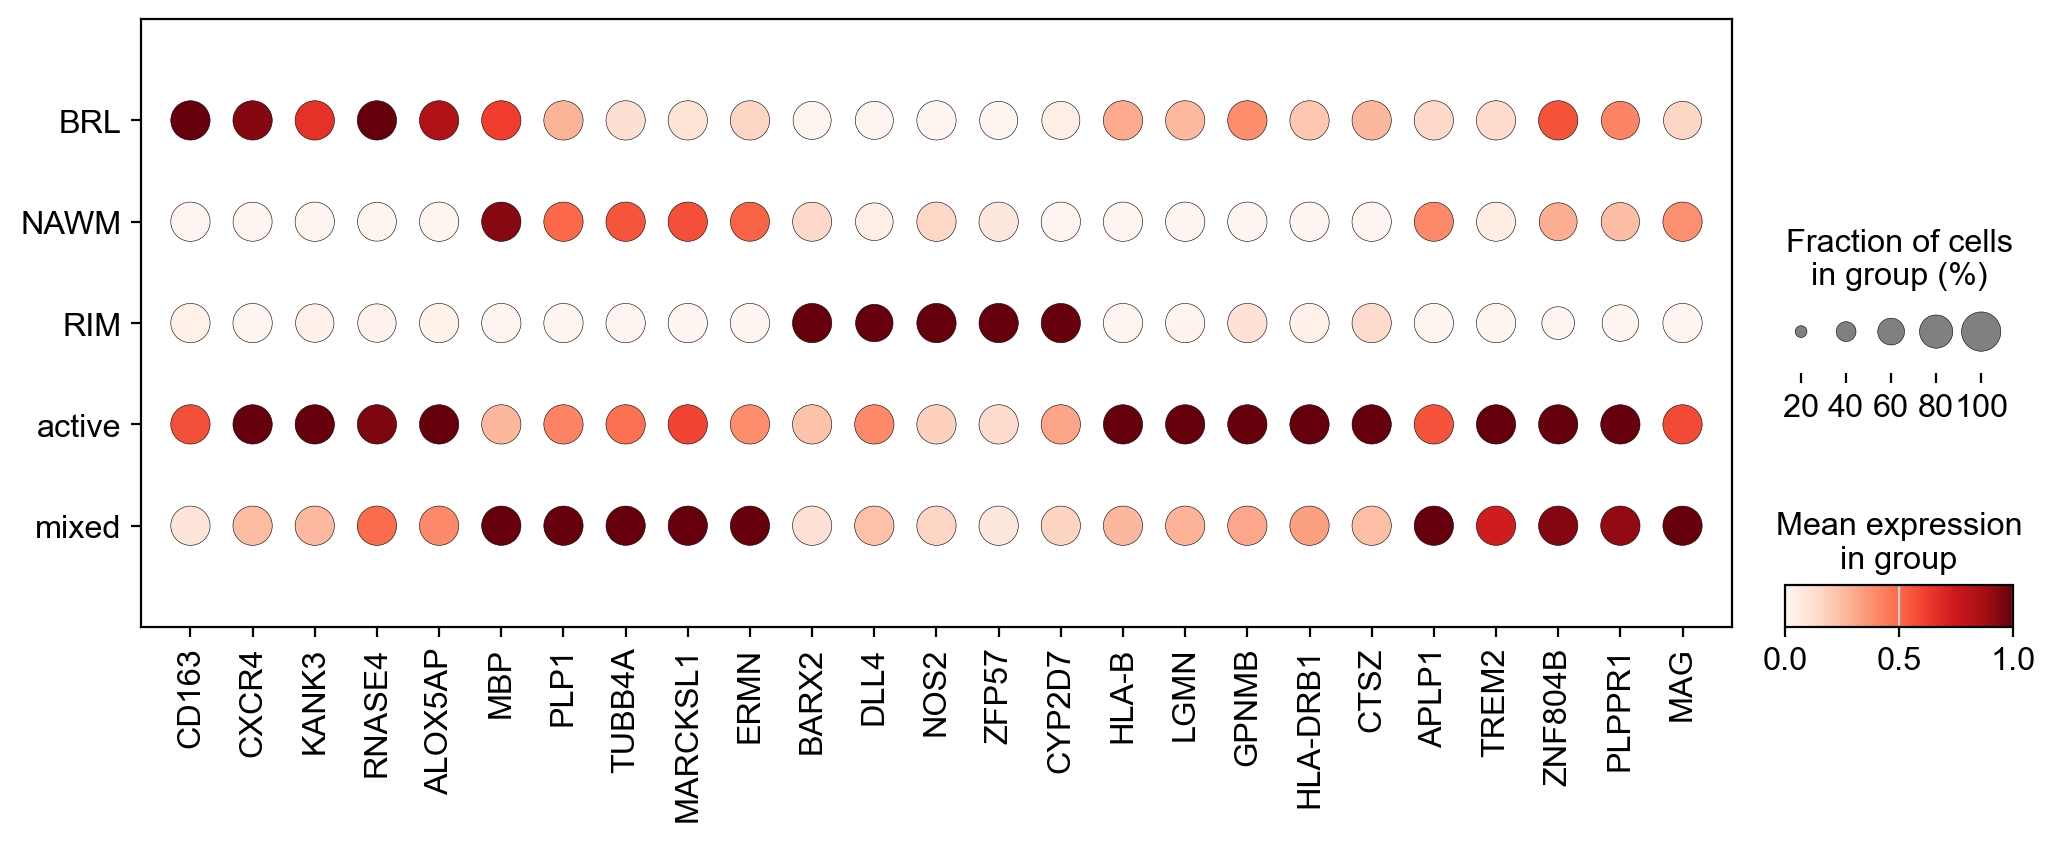

In [12]:
# Dotplot of top markers per lesion type
result = adata_ms.uns['rank_genes_groups']
top_genes = []
for group in result['names'].dtype.names:
    top_genes.extend(result['names'][group][:5])
top_genes = list(dict.fromkeys(top_genes))  # deduplicate, preserve order

sc.pl.dotplot(adata_ms, var_names=top_genes, groupby='lesion_type',
              standard_scale='var', figsize=(12, 4))

## 5. Key marker genes

Complement: missing {'C4A'}


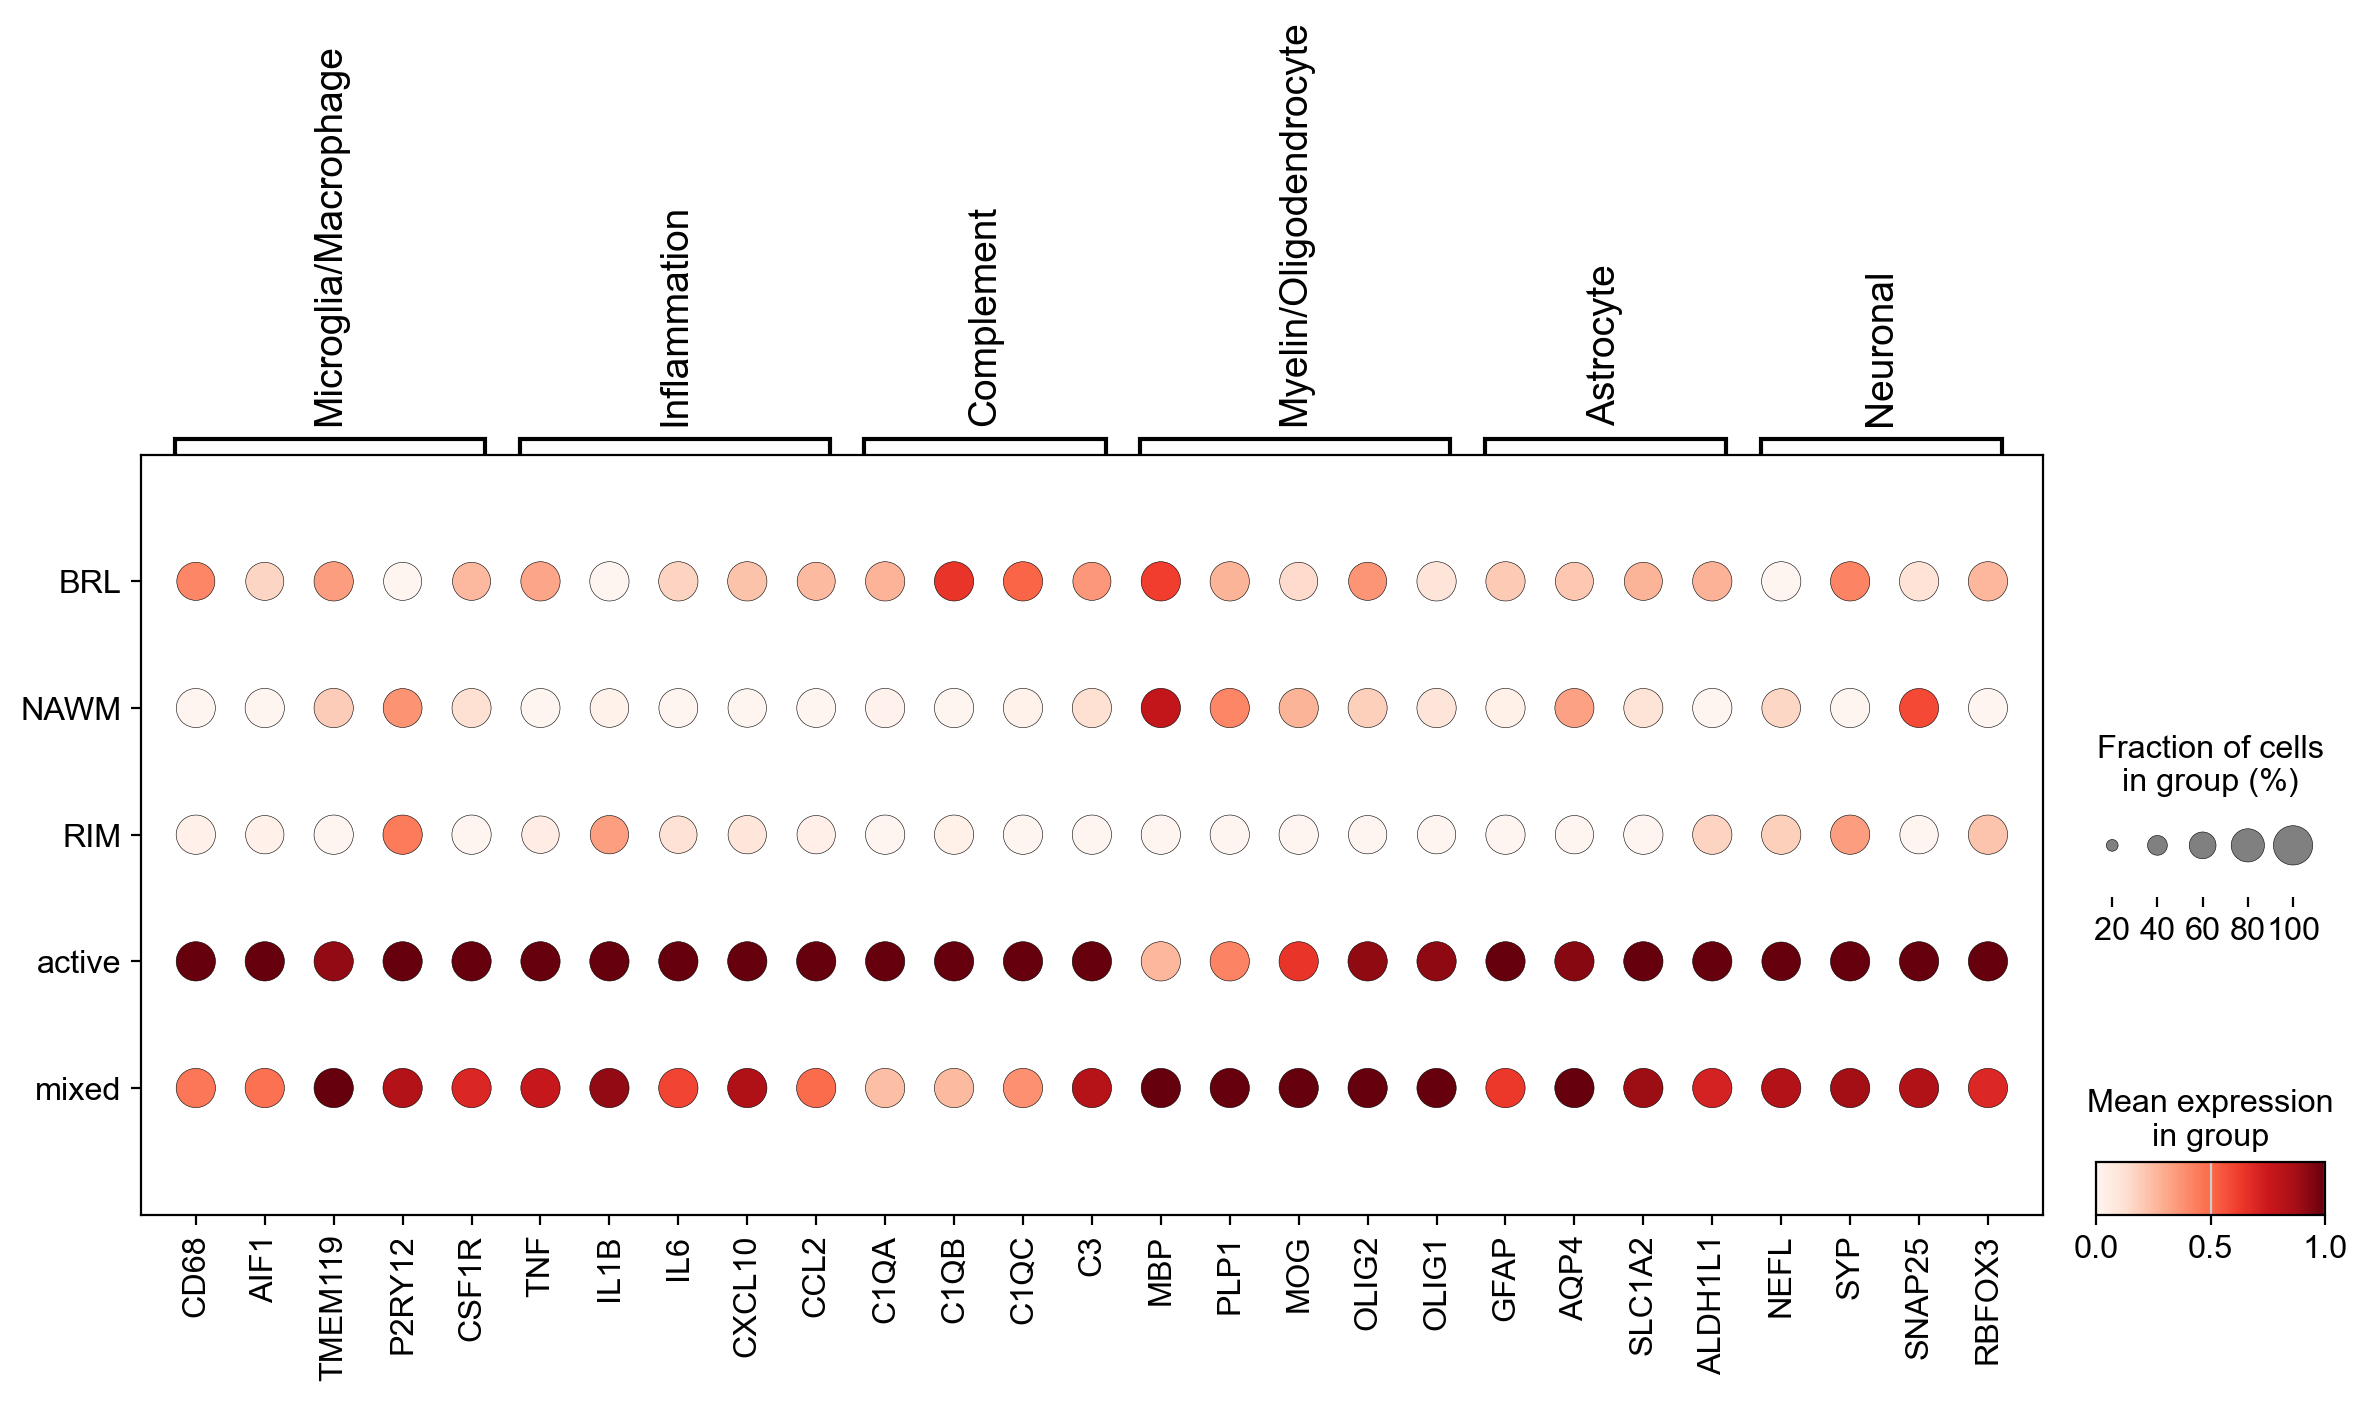

In [13]:
# Known markers for MS lesion biology
markers = {
    'Microglia/Macrophage': ['CD68', 'AIF1', 'TMEM119', 'P2RY12', 'CSF1R'],
    'Inflammation': ['TNF', 'IL1B', 'IL6', 'CXCL10', 'CCL2'],
    'Complement': ['C1QA', 'C1QB', 'C1QC', 'C3', 'C4A'],
    'Myelin/Oligodendrocyte': ['MBP', 'PLP1', 'MOG', 'OLIG2', 'OLIG1'],
    'Astrocyte': ['GFAP', 'AQP4', 'SLC1A2', 'ALDH1L1'],
    'Neuronal': ['NEFL', 'SYP', 'SNAP25', 'RBFOX3'],
}

# Filter to genes present in dataset
markers_present = {}
for cat, genes in markers.items():
    present = [g for g in genes if g in adata.var_names]
    if present:
        markers_present[cat] = present
        missing = set(genes) - set(present)
        if missing:
            print(f"{cat}: missing {missing}")

sc.pl.dotplot(adata, var_names=markers_present, groupby='lesion_type',
              standard_scale='var', figsize=(14, 5))

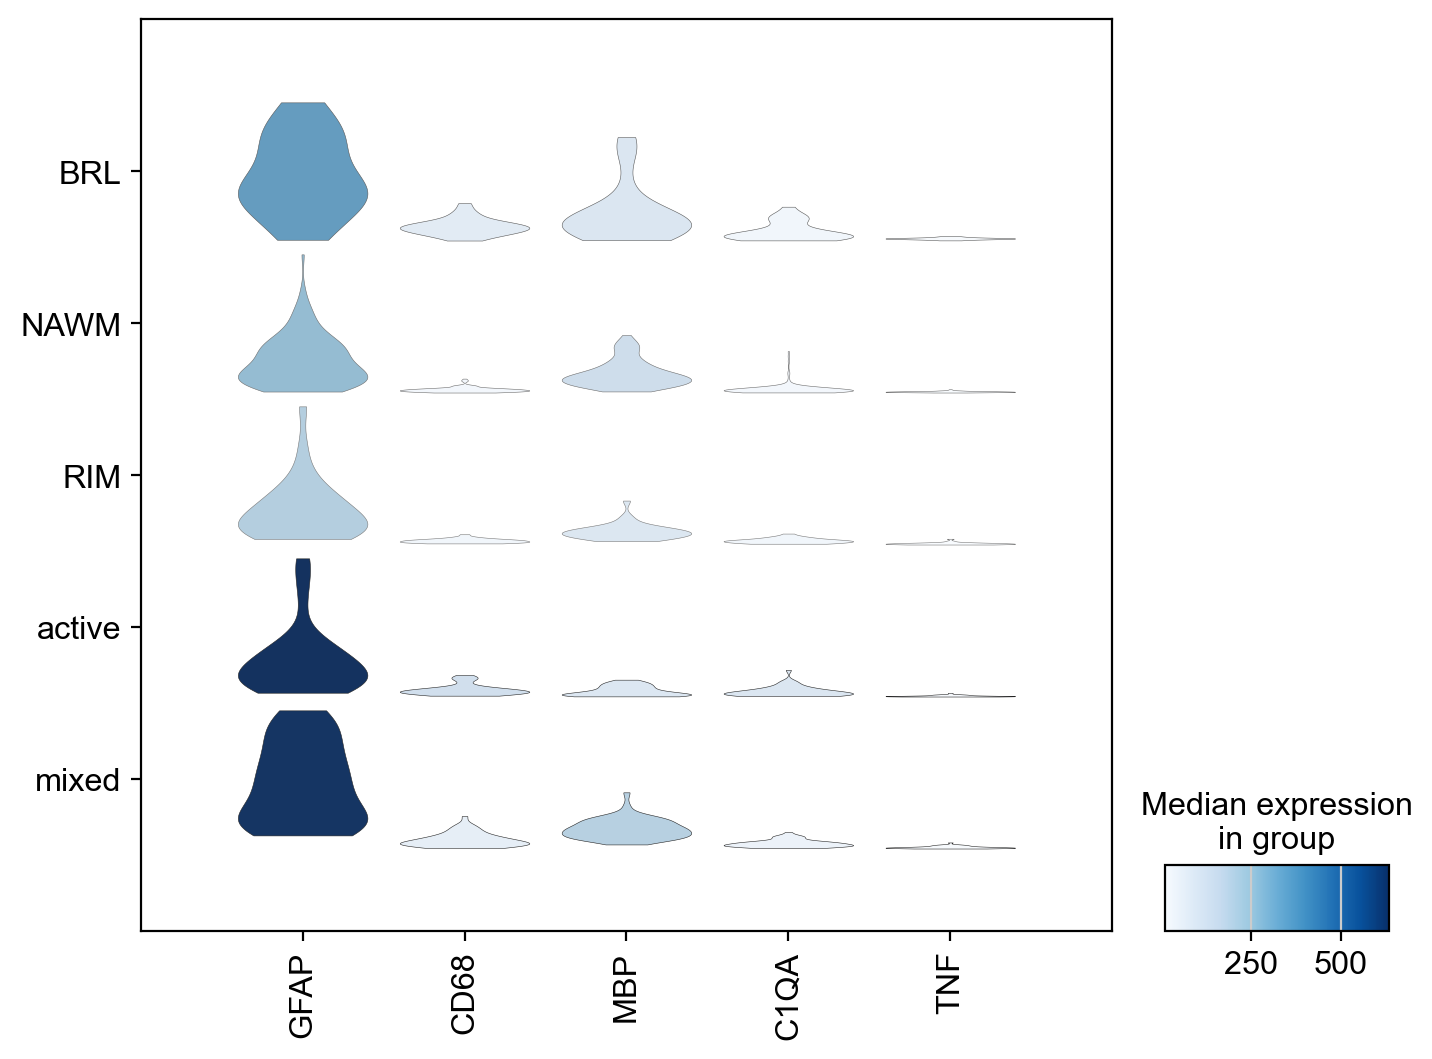

In [14]:
# Violin plots for key genes
key_genes = ['GFAP', 'CD68', 'MBP', 'C1QA', 'TNF']
key_genes = [g for g in key_genes if g in adata.var_names]

sc.pl.stacked_violin(adata, var_names=key_genes, groupby='lesion_type',
                     figsize=(8, 6))

## 6. MS vs Control

NAWM samples: 146 ({'MS': 125, 'control': 21})
ranking genes
    finished (0:00:00)


/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


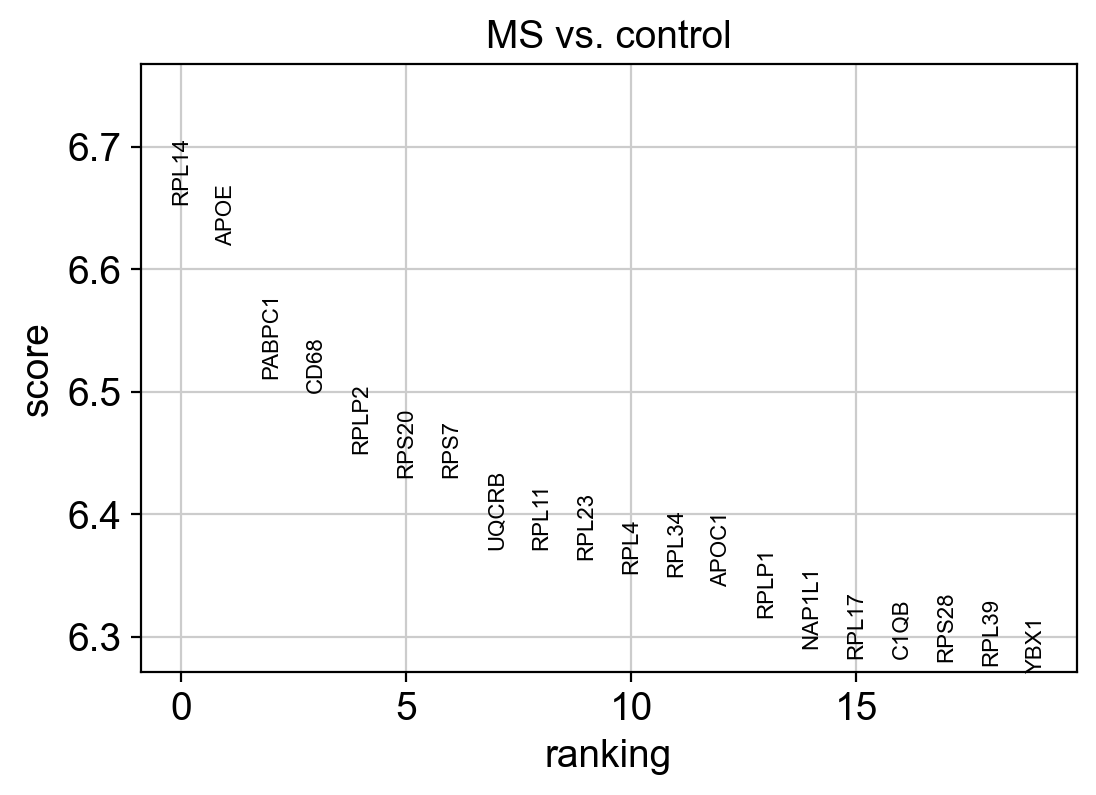

In [15]:
# Compare NAWM in MS vs controls
adata_nawm = adata[adata.obs['lesion_type'] == 'NAWM'].copy()
print(f"NAWM samples: {adata_nawm.shape[0]} ({adata_nawm.obs['condition'].value_counts().to_dict()})")

sc.tl.rank_genes_groups(adata_nawm, groupby='condition', method='wilcoxon',
                        reference='control')
sc.pl.rank_genes_groups(adata_nawm, n_genes=20, sharey=False)

## 7. Summary

In [16]:
print(f"Dataset: {adata.uns['dataset']}")
print(f"Platform: {adata.uns['platform']}")
print(f"Shape: {adata.shape[0]} ROIs x {adata.shape[1]} genes")
print(f"Patients: {adata.obs['patient'].nunique()} ({adata.obs['condition'].value_counts().to_dict()})")
print(f"\nLesion types:")
for lt, count in adata.obs['lesion_type'].value_counts().items():
    print(f"  {lt}: {count} ROIs")
print(f"\nLayers: {list(adata.layers.keys())}")
print(f"X contains: log1p(Q3-normalized counts)")

Dataset: GSE281807
Platform: NanoString GeoMx DSP
Shape: 296 ROIs x 18676 genes
Patients: 34 ({'MS': 275, 'control': 21})

Lesion types:
  NAWM: 146 ROIs
  mixed: 48 ROIs
  active: 46 ROIs
  RIM: 32 ROIs
  BRL: 24 ROIs

Layers: ['q3_norm']
X contains: log1p(Q3-normalized counts)


In [20]:
adata

AnnData object with n_obs × n_vars = 296 × 18676
    obs: 'gsm_id', 'scan_id', 'plate_id', 'well', 'raw_reads', 'trimmed_reads', 'aligned_reads', 'umi_q30', 'rts_q30', 'title', 'patient', 'lesion_type', 'replicate', 'condition', 'tissue', 'cell_type', 'location', 'total_counts', 'n_genes_detected', 'log_total_counts', 'pct_aligned'
    var: 'code_class', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dataset', 'organism', 'platform', 'title', 'hvg', 'pca', 'neighbors', 'umap', 'lesion_type_colors', 'condition_colors', 'patient_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'q3_norm'
    obsp: 'distances', 'connectivities'